# Split-Configuration Comparison on Winsorized Targets

Reproduces the June split-configuration comparison with the stabilized target pipeline: the raw year-over-year change is **winsorized at +/-3**, the improved pipeline trains on its **symlog transform**, and every metric is reported in **real (capped-change) units** for both the Baseline and Improved pipelines of the June notebook family (Baseline = full feature set, StandardScaler, pre-padded sequences; Improved = 26 selected temporal features, RobustScaler, packed sequences, static features).

Hyperparameters are the June Optuna winners (hardcoded, so the searches are skipped). Each configuration runs N_RUNS trainings per pipeline; evaluation inverts the symlog transform, so Baseline and Improved are directly comparable.

In [1]:
from pathlib import Path
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler, RobustScaler
from torch.utils.data import DataLoader, Dataset
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.optim.lr_scheduler import ReduceLROnPlateau
from IPython.display import display

SEED = 42
N_RUNS = 20
MAX_EPOCHS = 100
PATIENCE = 15
WINSOR_CAP = 3.0
LOOKBACK_DAYS = 365
MIN_WINDOW_OBS = 200
PREDICTION_TARGETS = ["EBITDA", "Net_Income", "ROA"]
RESULTS_DIR = "results_winsorized_splits"

DATA_CANDIDATES = [
    "Merged_Dataset_yoy.csv",
    "Dataset/Processed/Merged_Dataset_yoy.csv",
    "../Dataset/Processed/Merged_Dataset_yoy.csv",
    "../../Dataset/Processed/Merged_Dataset_yoy.csv",
]
DATA_PATH = next((Path(p) for p in DATA_CANDIDATES if Path(p).exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Merged_Dataset_yoy.csv not found (tried cwd and Dataset/Processed candidates).")

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(max(1, torch.get_num_threads() // 2))
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"Data: {DATA_PATH.resolve()}")

Using device: cuda
Data: /content/Merged_Dataset_yoy.csv


In [2]:
def load_and_prepare_yoy_data(data_path: Path, lookback_days: int = LOOKBACK_DAYS):
    df = pd.read_csv(data_path)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values(["Company", "Date"]).reset_index(drop=True)
    df["year"] = df["Date"].dt.year

    # Derived company-specific features (size-neutral transforms)
    df["Close_logret"] = df.groupby("Company")["Close"].transform(lambda x: np.log(x / x.shift(1)))
    df["Volume_log"] = np.log1p(df["Volume"].clip(lower=0))

    # Signed-log balance-sheet columns for the statics variant (absent from the current CSV)
    for _c in ["Total_Assets", "Total_Debt", "Cash"]:
        df[_c + "_symlog"] = np.sign(df[_c]) * np.log1p(df[_c].abs())

    df["has_targets"] = df[PREDICTION_TARGETS].notna().any(axis=1)
    year_end_records = df[df["has_targets"]].copy()
    exclude_cols = {"Date", "Company", "year", "has_targets"} | set(PREDICTION_TARGETS)
    feature_cols = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]

    sequences = []
    for company in df["Company"].unique():
        company_records = year_end_records[year_end_records["Company"] == company].copy()
        company_data = df[df["Company"] == company].copy()

        for _, year_end_row in company_records.iterrows():
            year = int(year_end_row["year"])
            year_end_date = year_end_row["Date"]

            prior_year_records = year_end_records[
                (year_end_records["Company"] == company) & (year_end_records["year"] == year - 1)
            ]
            if prior_year_records.empty:
                continue

            prior_row = prior_year_records.iloc[0]
            window_start = year_end_date - pd.Timedelta(days=lookback_days)
            window = company_data[(company_data["Date"] > window_start) & (company_data["Date"] <= year_end_date)].copy()

            if len(window) < MIN_WINDOW_OBS:
                continue

            window[feature_cols] = window[feature_cols].ffill().bfill()
            if window[feature_cols].isna().any().any():
                continue

            static_cols = ["MC_MIB", "MC_MID", "MC_SMALL",
                           "Total_Assets_symlog", "Total_Debt_symlog", "Cash_symlog"]
            static_data = window[static_cols].iloc[-1].to_numpy(dtype=np.float32)

            sequences.append({
                "company": company, "year": year, "year_end_date": year_end_date,
                "window_data": window[feature_cols].to_numpy(dtype=np.float32),
                "static_data": static_data,
                **{f"current_{t.lower()}": year_end_row[t] for t in PREDICTION_TARGETS},
                **{f"prior_{t.lower()}": prior_row[t] for t in PREDICTION_TARGETS},
            })

    data_records = []
    for seq in sequences:
        for target_name in PREDICTION_TARGETS:
            current_val = seq[f"current_{target_name.lower()}"]
            prior_val = seq[f"prior_{target_name.lower()}"]
            if pd.isna(current_val) or pd.isna(prior_val):
                continue

            label_value = (current_val - prior_val) / (np.abs(prior_val) + 1e-8)

            data_records.append({
                "company": seq["company"], "year": seq["year"], "year_end_date": seq["year_end_date"],
                "target": target_name, "label_value": label_value,
                "window_data": seq["window_data"],
                "static_data": seq["static_data"]
            })

    return pd.DataFrame(data_records), feature_cols

data_df, feature_cols = load_and_prepare_yoy_data(DATA_PATH)
print(f"Records: {len(data_df)} | firms: {data_df['company'].nunique()} | temporal features: {len(feature_cols)}")


Records: 5712 | firms: 161 | temporal features: 55


In [3]:
# Winsorize the raw YoY change at +/-3: this defines the task for BOTH pipelines.
# The improved pipeline applies symlog on top of the capped values (monotonic, so
# symlog(capped) == capped-symlog); the baseline stays in real capped units.
n_capped = int((data_df["label_value"].abs() > WINSOR_CAP).sum())
data_df["label_value"] = data_df["label_value"].clip(-WINSOR_CAP, WINSOR_CAP)
print(f"Winsorized raw YoY change at +/-{WINSOR_CAP}: "
      f"{n_capped}/{len(data_df)} ({100.0 * n_capped / len(data_df):.2f}%) samples capped")
print(f"Capped label range: [{data_df['label_value'].min():.4f}, {data_df['label_value'].max():.4f}]")

max_seq_length = max(len(row) for row in data_df["window_data"])
print(f"Max sequence length: {max_seq_length}")

Winsorized raw YoY change at +/-3.0: 487/5712 (8.53%) samples capped
Capped label range: [-3.0000, 3.0000]
Max sequence length: 260


## Datasets, models, training and evaluation

In [4]:
def extract_mtl_df(df: pd.DataFrame) -> pd.DataFrame:
    mtl_records = []
    for (company, year), group in df.groupby(["company", "year"]):
        mtl_records.append({
            "company": company, "year": year, "year_end_date": group.iloc[0]["year_end_date"],
            "window_data": group.iloc[0]["window_data"],
            "static_data": group.iloc[0]["static_data"],
            "label_value": np.array([group[group["target"] == t].iloc[0]["label_value"]
                                     if not group[group["target"] == t].empty else np.nan
                                     for t in PREDICTION_TARGETS], dtype=np.float32),
        })
    return pd.DataFrame(mtl_records)


class ShallowLSTMClassifier(nn.Module):
    """Baseline pipeline model: full feature set, StandardScaler, pre-padded sequences."""
    def __init__(self, input_size: int, hidden_size: int, num_targets: int = 3, dropout: float = 0.2, static_dim: int = 0):
        super().__init__()
        self.static_dim = static_dim
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(hidden_size + static_dim, num_targets)

    def forward(self, x, static=None):
        lstm_out, _ = self.lstm(x)
        hidden = self.dropout(lstm_out[:, -1, :])
        if self.static_dim > 0 and static is not None:
            hidden = torch.cat([hidden, static.to(hidden.device, hidden.dtype)], dim=-1)
        logits = self.head(hidden)
        if logits.size(-1) == 1: logits = logits.squeeze(-1)
        return logits


class ImprovedShallowLSTM(nn.Module):
    """Improved pipeline model: selected features, RobustScaler, packed sequences."""
    def __init__(self, input_size: int, hidden_size: int, num_targets: int = 3, dropout: float = 0.2, static_dim: int = 0):
        super().__init__()
        self.static_dim = static_dim
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(p=dropout)
        self.head = nn.Linear(hidden_size + static_dim, num_targets)

    def forward(self, x, lengths, static=None):
        packed_x = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=True)
        _, (hn, _) = self.lstm(packed_x)
        hidden = self.dropout(hn[-1])
        if self.static_dim > 0 and static is not None:
            hidden = torch.cat([hidden, static.to(hidden.device, hidden.dtype)], dim=-1)
        logits = self.head(hidden)
        if logits.size(-1) == 1: logits = logits.squeeze(-1)
        return logits


class YoYSequenceDatasetMTL(Dataset):
    """Baseline pipeline dataset: StandardScaler + pre-padding to max_seq_length."""
    def __init__(self, data_df: pd.DataFrame, max_seq_length: int, scaler: StandardScaler = None, n_static: int = None):
        self.data_df = data_df.reset_index(drop=True)
        self.max_seq_length = max_seq_length
        self.scaler = scaler
        self.n_static = n_static

    def __len__(self): return len(self.data_df)

    def __getitem__(self, idx: int):
        row = self.data_df.iloc[idx]
        window = row["window_data"].copy()
        if self.scaler is not None: window = self.scaler.transform(window)
        seq_len = len(window)
        if seq_len < self.max_seq_length:
            padding = np.zeros((self.max_seq_length - seq_len, window.shape[1]), dtype=np.float32)
            window = np.vstack([padding, window])
        static = row["static_data"].astype(np.float32)
        if self.n_static is not None: static = static[:self.n_static]
        static = np.nan_to_num(static, nan=0.0)
        target = row["label_value"]
        mask = ~np.isnan(target)
        target_clean = np.nan_to_num(target, nan=0.0)
        return torch.from_numpy(window), torch.from_numpy(static), torch.tensor(target_clean, dtype=torch.float32), torch.tensor(mask, dtype=torch.bool)


class ImprovedYoYDatasetMTL(Dataset):
    """Improved pipeline dataset: RobustScaler + selected features + packing."""
    def __init__(self, data_df, scaler, feature_indices, n_static: int = None):
        self.data_df = data_df.reset_index(drop=True)
        self.scaler = scaler
        self.feature_indices = feature_indices
        self.n_static = n_static

    def __len__(self): return len(self.data_df)

    def __getitem__(self, idx):
        row = self.data_df.iloc[idx]
        window = row["window_data"][:, self.feature_indices].copy()
        if self.scaler: window = self.scaler.transform(window)
        static = row["static_data"].astype(np.float32)
        if self.n_static is not None: static = static[:self.n_static]
        static = np.nan_to_num(static, nan=0.0)
        target = row["label_value"]
        mask = ~np.isnan(target)
        target_clean = np.nan_to_num(target, nan=0.0)
        return (torch.from_numpy(window), torch.from_numpy(static),
                torch.tensor(target_clean, dtype=torch.float32), torch.tensor(mask, dtype=torch.bool), len(window))


def collate_fn_improved_mtl(batch):
    batch.sort(key=lambda x: x[4], reverse=True)
    sequences = [x[0] for x in batch]
    statics = torch.stack([x[1] for x in batch])
    targets = torch.stack([x[2] for x in batch])
    masks = torch.stack([x[3] for x in batch])
    lengths = torch.tensor([x[4] for x in batch])
    padded_seqs = pad_sequence(sequences, batch_first=True)
    return padded_seqs, targets, masks, statics, lengths


In [5]:
SELECTED_FEATURES = [
    'Close_logret', 'Volume_log',
    'DE10YT_Yield', 'EURUSD_Close', 'EURUSD_Volume', 'Euribor_3M', 'FTMIB_Volume',
    'GVZ_Close', 'IT_Inflation', 'Brent_Close', 'OVX_Close', 'TTF_Gas_Close',
    'VIX_Close', 'Gold_Close', 'YC__level', 'YC__slope', 'YC__curv',
    'PCOPPUSDM', 'PALUMUSDM', 'NFCI', 'ff_HML', 'ff_Mom',
    'FTMIB_Close', 'IT10YT_Yield', 'IT_Unemployment', 'Brent_Volume'
]
selected_indices = [feature_cols.index(f) for f in SELECTED_FEATURES]
print(f"Selected temporal features ({len(selected_indices)})")

Selected temporal features (26)


In [6]:
def train_and_eval(model, train_loader, val_loader, optimizer, is_improved):
    """Training loss is L1 in the pipeline's optimized space (symlog for the
    improved pipeline, real for the baseline). The validation metric used for
    early stopping and checkpointing is REAL-space MAE for both pipelines.
    Returns (model, best_metric, history) with per-epoch curves."""
    criterion = nn.L1Loss(reduction='none')
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    best_state = None
    best_metric = float("inf")
    best_epoch = 0
    epochs_without_improvement = 0
    history = {"train_loss": [], "val_mae": []}

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        epoch_loss_sum, epoch_loss_count = 0.0, 0
        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            if is_improved:
                bx, by, bmask, bstatic, lengths = batch
                bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                logits = model(bx, lengths, bstatic)
            else:
                bx, bstatic, by, bmask = batch
                bx, by, bmask, bstatic = bx.to(DEVICE), by.to(DEVICE), bmask.to(DEVICE), bstatic.to(DEVICE)
                logits = model(bx, bstatic)
            loss_m = criterion(logits, by)
            loss = loss_m[bmask].mean() if loss_m[bmask].numel() > 0 else 0*loss_m.sum()
            if isinstance(loss, torch.Tensor) and loss.requires_grad:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                epoch_loss_sum += float(loss.detach())
                epoch_loss_count += 1
        history["train_loss"].append(epoch_loss_sum / max(1, epoch_loss_count))

        model.eval()
        all_preds, all_targets, all_masks = [], [], []
        with torch.no_grad():
            for batch in val_loader:
                if is_improved:
                    bx, by, bmask, bstatic, lengths = batch
                    logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
                else:
                    bx, bstatic, by, bmask = batch
                    logits = model(bx.to(DEVICE), bstatic.to(DEVICE))
                all_preds.append(logits.cpu().numpy())
                all_targets.append(by.numpy())
                all_masks.append(bmask.numpy())

        if not all_preds:
            break
        y_pred = np.vstack(all_preds)
        y_true = np.vstack(all_targets)
        if is_improved:
            y_pred = np.sign(y_pred) * np.expm1(np.abs(y_pred))
            y_true = np.sign(y_true) * np.expm1(np.abs(y_true))
        mask = np.vstack(all_masks)
        valid_sum, count = 0, 0
        for i in range(len(PREDICTION_TARGETS)):
            m = mask[:, i]
            if m.sum() == 0: continue
            valid_sum += np.mean(np.abs(y_pred[m, i] - y_true[m, i]))
            count += 1
        current_metric = float(valid_sum / max(1, count))
        history["val_mae"].append(current_metric)

        scheduler.step(current_metric)
        if current_metric < best_metric:
            best_metric = current_metric
            best_epoch = epoch
            best_state = {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    history["best_epoch"] = best_epoch
    return model, best_metric, history

In [7]:
def build_loaders_and_model(is_improved, params, mtl_train, mtl_val, mtl_test, n_static, scaler, robust_scaler):
    dropout_val = params.get("dropout", 0.2)
    if is_improved:
        train_ds = ImprovedYoYDatasetMTL(mtl_train, robust_scaler, selected_indices, n_static=n_static)
        val_ds   = ImprovedYoYDatasetMTL(mtl_val,   robust_scaler, selected_indices, n_static=n_static)
        test_ds  = ImprovedYoYDatasetMTL(mtl_test,  robust_scaler, selected_indices, n_static=n_static)
        collate = collate_fn_improved_mtl
        model = ImprovedShallowLSTM(len(selected_indices), params["hidden_size"], len(PREDICTION_TARGETS), dropout_val, static_dim=n_static).to(DEVICE)
    else:
        train_ds = YoYSequenceDatasetMTL(mtl_train, max_seq_length, scaler, n_static=n_static)
        val_ds   = YoYSequenceDatasetMTL(mtl_val,   max_seq_length, scaler, n_static=n_static)
        test_ds  = YoYSequenceDatasetMTL(mtl_test,  max_seq_length, scaler, n_static=n_static)
        collate = None
        model = ShallowLSTMClassifier(len(feature_cols), params["hidden_size"], len(PREDICTION_TARGETS), dropout_val, static_dim=n_static).to(DEVICE)
    if collate:
        train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True, collate_fn=collate)
        val_loader   = DataLoader(val_ds,   batch_size=params["batch_size"], shuffle=False, collate_fn=collate)
        test_loader  = DataLoader(test_ds,  batch_size=params["batch_size"], shuffle=False, collate_fn=collate)
    else:
        train_loader = DataLoader(train_ds, batch_size=params["batch_size"], shuffle=True)
        val_loader   = DataLoader(val_ds,   batch_size=params["batch_size"], shuffle=False)
        test_loader  = DataLoader(test_ds,  batch_size=params["batch_size"], shuffle=False)
    return model, train_loader, val_loader, test_loader


def evaluate_loader(model, loader, is_improved):
    """Real-space (capped-change) metrics. nMAE% and R2 follow the convention of
    ratio_size_normalized_targets.ipynb: per seed, nMAE% = 100 * MAE / mean|actual|
    and R2 = 1 - SS_res/SS_tot, computed on the capped targets of this task."""
    model.eval()
    all_preds, all_targets, all_masks = [], [], []
    with torch.no_grad():
        for batch in loader:
            if is_improved:
                bx, by, bmask, bstatic, lengths = batch
                logits = model(bx.to(DEVICE), lengths, bstatic.to(DEVICE))
            else:
                bx, bstatic, by, bmask = batch
                logits = model(bx.to(DEVICE), bstatic.to(DEVICE))
            all_preds.append(logits.cpu().numpy())
            all_targets.append(by.numpy())
            all_masks.append(bmask.numpy())
    if not all_preds:
        return None
    y_pred = np.vstack(all_preds)
    y_true = np.vstack(all_targets)
    if is_improved:
        y_pred = np.sign(y_pred) * np.expm1(np.abs(y_pred))
        y_true = np.sign(y_true) * np.expm1(np.abs(y_true))
    mask = np.vstack(all_masks)
    res = {}
    all_errors = []
    nmae_list, r2_list = [], []
    for i, t in enumerate(PREDICTION_TARGETS):
        m = mask[:, i]
        if m.sum() == 0:
            res[t] = {"mae": float("nan"), "nmae_pct": float("nan"), "r2": float("nan")}
            continue
        p, a = y_pred[m, i], y_true[m, i]
        mae = float(np.mean(np.abs(p - a)))
        nmae_pct = 100.0 * mae / float(np.mean(np.abs(a)))
        ss_res = float(np.sum((p - a) ** 2))
        ss_tot = float(np.sum((a - a.mean()) ** 2))
        r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else float("nan")
        res[t] = {"mae": mae, "nmae_pct": nmae_pct, "r2": r2}
        nmae_list.append(nmae_pct)
        r2_list.append(r2)
        all_errors.extend(np.abs(p - a).tolist())
    res["Overall"] = {
        "mae": float(np.mean(all_errors)) if all_errors else None,
        "nmae_pct": float(np.mean(nmae_list)) if nmae_list else None,
        "r2": float(np.mean(r2_list)) if r2_list else None,
    }
    return res


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)

## Run each configuration - one cell per model, curves plotted right after each

In [8]:
PARAMS_BASELINE = {
    "hidden_size": 32, "lr": 0.0070588483087296325, "batch_size": 32,
    "weight_decay": 1.9589303745791975e-05, "dropout": 0.3087390000049251,
}
PARAMS_IMPROVED = {
    "hidden_size": 64, "lr": 0.004281715841846713, "batch_size": 32,
    "weight_decay": 9.71966031081484e-06, "dropout": 0.39475799480215,
}

CONFIGS = [
    {"name": "Final single split",         "train_max": 2022, "val_max": 2023, "n_static": 3},
    {"name": "With balance-sheet statics", "train_max": 2022, "val_max": 2023, "n_static": 6},
]

if "all_results" not in globals():
    all_results = {}
os.makedirs(RESULTS_DIR, exist_ok=True)


def split_by_year(df, train_max_year, val_max_year):
    train = df[df["year"] <= train_max_year].copy()
    val = df[(df["year"] > train_max_year) & (df["year"] <= val_max_year)].copy()
    test = df[df["year"] > val_max_year].copy()
    print(f"  Split: train <= {train_max_year} ({len(train)}), "
          f"val {train_max_year + 1}-{val_max_year} ({len(val)}), "
          f"test > {val_max_year} ({len(test)})")
    return train, val, test


def make_scaler(train_df):
    sc = StandardScaler()
    sc.fit(np.vstack(train_df["window_data"].values))
    return sc


def make_robust_scaler(train_df, feature_indices):
    sc = RobustScaler()
    sc.fit(np.vstack([row[:, feature_indices] for row in train_df["window_data"]]))
    return sc


def plot_avg_curves(name, pipeline_name, histories):
    """Averaged train/val curves (mean +/- 1 std over runs, NaN-aligned epochs).
    Train loss is in the pipeline's optimized space (symlog for Improved,
    real for Baseline); val MAE is in real capped-change units for both."""
    max_ep = max(len(h["train_loss"]) for h in histories)

    def stack(key):
        arr = np.full((len(histories), max_ep), np.nan)
        for i, h in enumerate(histories):
            v = h[key]
            arr[i, :len(v)] = v
        return arr

    tl, vm = stack("train_loss"), stack("val_mae")
    ep = np.arange(1, max_ep + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    panels = [
        (axes[0], tl, f"Train loss ({'symlog space' if pipeline_name == 'Improved' else 'real-space L1'})"),
        (axes[1], vm, "Val MAE (real capped-change units)"),
    ]
    for ax, data, ylab in panels:
        mean = np.nanmean(data, axis=0)
        std = np.nanstd(data, axis=0)
        ax.plot(ep, mean, linewidth=1.8, label=f"{pipeline_name} (mean of {len(histories)} runs)")
        ax.fill_between(ep, mean - std, mean + std, alpha=0.2, label="+/- 1 std")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylab)
        ax.grid(True, alpha=0.3)
        ax.legend()
    fig.suptitle(f"{name} - {pipeline_name}: training dynamics ({len(histories)}-run average)")
    plt.tight_layout()
    os.makedirs("figures", exist_ok=True)
    slug = f"{name.lower().replace(' ', '_')}_{pipeline_name.lower()}"
    plt.savefig(f"figures/loss_curves_{slug}.png", dpi=150)
    plt.show()


def run_pipeline(cfg, pipeline_name, is_improved, params):
    """Runs N_RUNS seeds for one (config, pipeline) pair: MAE, nMAE% and R2 per
    target and Overall (mean +/- std over seeds), averaged train/val curves,
    and JSON persistence so results survive a Colab disconnect."""
    name, train_max, val_max = cfg["name"], cfg["train_max"], cfg["val_max"]
    n_static = cfg["n_static"]
    print(f"=== {name} | {pipeline_name} (statics: {n_static}) ===")
    if is_improved:
        df_p = data_df.copy()
        df_p["label_value"] = np.sign(df_p["label_value"]) * np.log1p(np.abs(df_p["label_value"]))
        train_p, val_p, test_p = split_by_year(df_p, train_max, val_max)
    else:
        train_p, val_p, test_p = split_by_year(data_df, train_max, val_max)

    mtl_train = extract_mtl_df(train_p)
    mtl_val = extract_mtl_df(val_p)
    mtl_test = extract_mtl_df(test_p)

    cfg_scaler = make_scaler(train_p) if not is_improved else None
    cfg_robust = make_robust_scaler(train_p, selected_indices) if is_improved else None

    agg = {t: {"mae": [], "nmae_pct": [], "r2": []} for t in PREDICTION_TARGETS + ["Overall"]}
    histories = []
    t_start = time.time()
    for run_idx in range(N_RUNS):
        set_seed(SEED + run_idx)
        model, train_loader, val_loader, test_loader = build_loaders_and_model(
            is_improved, params, mtl_train, mtl_val, mtl_test, n_static, cfg_scaler, cfg_robust)
        optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"],
                                     weight_decay=params["weight_decay"])
        model, _, history = train_and_eval(model, train_loader, val_loader, optimizer,
                                           is_improved=is_improved)
        histories.append(history)
        res = evaluate_loader(model, test_loader, is_improved=is_improved)
        for k in agg:
            for m in ("mae", "nmae_pct", "r2"):
                agg[k][m].append(res[k][m])
        if (run_idx + 1) % 5 == 0:
            print(f"  run {run_idx + 1}/{N_RUNS}: Overall MAE so far "
                  f"{np.mean(agg['Overall']['mae']):.4f}")

    summary = {k: {m: (float(np.mean(v)), float(np.std(v))) for m, v in mv.items()}
               for k, mv in agg.items()}

    print(f"\n{pipeline_name} final test (n={N_RUNS} runs):")
    for t in PREDICTION_TARGETS + ["Overall"]:
        m, sd = summary[t]["mae"]
        print(f"  {t:11s}: {m:.4f} +/- {sd:.4f}")
    print(f"  Scale-free metrics (capped targets):")
    for t in PREDICTION_TARGETS:
        nm, nm_s = summary[t]["nmae_pct"]
        r2, r2_s = summary[t]["r2"]
        print(f"    {t:11s}: nMAE {nm:.1f}% +/- {nm_s:.1f}% | R2 {r2:.3f} +/- {r2_s:.3f}")
    print(f"Time: {(time.time() - t_start) / 60:.1f} min")

    plot_avg_curves(name, pipeline_name, histories)

    slug = f"{name.lower().replace(' ', '_')}_{pipeline_name.lower()}"
    payload = {"config": name, "pipeline": pipeline_name, "n_static": n_static,
               "summary": summary, "histories": histories}
    with open(f"{RESULTS_DIR}/{slug}.json", "w") as f:
        json.dump(payload, f, default=float)
    all_results.setdefault(name, {})[pipeline_name] = summary
    return summary

## Five-fold TSCV - per-split results (5 seeds per fold)

Each fold trains on all years **before** its validation year (expanding window) and is
evaluated in real capped-change units on that single validation year. Results are
printed per fold and persisted to `results_tscv/` immediately, so a Colab disconnect
never loses completed folds; rerunning these cells skips the cached ones.

In [9]:
FOLD_YEARS = [2019, 2020, 2021, 2022, 2023]
N_SEEDS_FOLD = 5
RESULTS_TSCV_DIR = "results_tscv"
os.makedirs(RESULTS_TSCV_DIR, exist_ok=True)


def run_tscv_fold(fold_year, pipeline_name, is_improved, params):
    """One TSCV fold: train on all years before `fold_year`, evaluate on that year.
    Per target and Overall: MAE, nMAE% (100*MAE/mean|actual|) and R2, following the
    ratio_size_normalized_targets.ipynb convention. Persists per fold immediately."""
    pipeline_slug = pipeline_name.lower()
    fpath = Path(RESULTS_TSCV_DIR) / f"fold_{fold_year}_{pipeline_slug}.json"
    if fpath.exists():
        with open(fpath) as f:
            payload = json.load(f)
        print(f"Fold {fold_year} | {pipeline_name}: cached results loaded from {fpath}")
        all_results.setdefault("Five-fold TSCV", {}).setdefault(pipeline_name, {})[fold_year] = payload["summary"]
        return payload["summary"]

    print(f"\n=== Five-fold TSCV | Fold {fold_year} | {pipeline_name} ===")
    n_static = 3  # TSCV folds use the market-cap-only statics (June kfold configuration)
    if is_improved:
        df_p = data_df.copy()
        df_p["label_value"] = np.sign(df_p["label_value"]) * np.log1p(np.abs(df_p["label_value"]))
        train_p = df_p[df_p["year"] < fold_year].copy()
        val_p = df_p[df_p["year"] == fold_year].copy()
    else:
        train_p = data_df[data_df["year"] < fold_year].copy()
        val_p = data_df[data_df["year"] == fold_year].copy()
    print(f"  Fold split: train <= {fold_year - 1} ({len(train_p)}), val = {fold_year} ({len(val_p)})")

    mtl_train = extract_mtl_df(train_p)
    mtl_val = extract_mtl_df(val_p)

    # scalers refitted on this fold's training windows only (no leakage)
    cfg_scaler = make_scaler(train_p) if not is_improved else None
    cfg_robust = make_robust_scaler(train_p, selected_indices) if is_improved else None

    # NOTE: the third loader of build_loaders_and_model plays the role of the
    # fold's validation-year set here; evaluation targets it directly.
    agg = {t: {"mae": [], "nmae_pct": [], "r2": []} for t in PREDICTION_TARGETS + ["Overall"]}
    histories = []
    t_start = time.time()
    for run_idx in range(N_SEEDS_FOLD):
        set_seed(SEED + run_idx)
        model, train_loader, val_loader, fold_loader = build_loaders_and_model(
            is_improved, params, mtl_train, mtl_val, mtl_val, n_static, cfg_scaler, cfg_robust)
        optimizer = torch.optim.Adam(model.parameters(), lr=params["lr"],
                                     weight_decay=params["weight_decay"])
        model, _, history = train_and_eval(model, train_loader, val_loader, optimizer,
                                           is_improved=is_improved)
        histories.append(history)
        res = evaluate_loader(model, fold_loader, is_improved=is_improved)
        for k in agg:
            for m in ("mae", "nmae_pct", "r2"):
                agg[k][m].append(res[k][m])
        print(f"  seed {run_idx + 1}/{N_SEEDS_FOLD}: Overall MAE {res['Overall']['mae']:.4f}")

    summary = {k: {m: (float(np.mean(v)), float(np.std(v))) for m, v in mv.items()}
               for k, mv in agg.items()}

    print(f"\nFold {fold_year} | {pipeline_name} final test (n={N_SEEDS_FOLD} seeds):")
    for t in PREDICTION_TARGETS + ["Overall"]:
        m, sd = summary[t]["mae"]
        print(f"  {t:11s}: {m:.4f} +/- {sd:.4f}")
    print(f"  Scale-free metrics (capped targets):")
    for t in PREDICTION_TARGETS:
        nm, nm_s = summary[t]["nmae_pct"]
        r2, r2_s = summary[t]["r2"]
        print(f"    {t:11s}: nMAE {nm:.1f}% +/- {nm_s:.1f}% | R2 {r2:.3f} +/- {r2_s:.3f}")
    print(f"Time: {(time.time() - t_start) / 60:.1f} min")

    payload = {"config": "Five-fold TSCV", "fold_year": fold_year, "pipeline": pipeline_name,
               "n_seeds": N_SEEDS_FOLD, "summary": summary, "histories": histories}
    with open(fpath, "w") as f:
        json.dump(payload, f, default=float)
    all_results.setdefault("Five-fold TSCV", {}).setdefault(pipeline_name, {})[fold_year] = summary
    return summary


def run_tscv_pipeline(pipeline_name, is_improved, params):
    for fold_year in FOLD_YEARS:
        run_tscv_fold(fold_year, pipeline_name, is_improved, params)

### Baseline

In [10]:
run_tscv_pipeline("Baseline", is_improved=False, params=PARAMS_BASELINE)


=== Five-fold TSCV | Fold 2019 | Baseline ===
  Fold split: train <= 2018 (2722), val = 2019 (368)
  seed 1/5: Overall MAE 0.6497
  seed 2/5: Overall MAE 0.6517
  seed 3/5: Overall MAE 0.6613
  seed 4/5: Overall MAE 0.6485
  seed 5/5: Overall MAE 0.6607

Fold 2019 | Baseline final test (n=5 seeds):
  EBITDA     : 0.5215 +/- 0.0090
  Net_Income : 0.7262 +/- 0.0069
  ROA        : 0.7145 +/- 0.0172
  Overall    : 0.6544 +/- 0.0055
  Scale-free metrics (capped targets):
    EBITDA     : nMAE 95.7% +/- 1.6% | R2 -0.028 +/- 0.015
    Net_Income : nMAE 99.3% +/- 0.9% | R2 0.005 +/- 0.005
    ROA        : nMAE 99.0% +/- 2.4% | R2 -0.002 +/- 0.015
Time: 1.5 min

=== Five-fold TSCV | Fold 2020 | Baseline ===
  Fold split: train <= 2019 (3090), val = 2020 (392)
  seed 1/5: Overall MAE 0.8396
  seed 2/5: Overall MAE 0.8531
  seed 3/5: Overall MAE 0.8363
  seed 4/5: Overall MAE 0.8383
  seed 5/5: Overall MAE 0.8224

Fold 2020 | Baseline final test (n=5 seeds):
  EBITDA     : 0.5471 +/- 0.0106
  Ne

### Improved

In [11]:
run_tscv_pipeline("Improved", is_improved=True, params=PARAMS_IMPROVED)


=== Five-fold TSCV | Fold 2019 | Improved ===
  Fold split: train <= 2018 (2722), val = 2019 (368)
  seed 1/5: Overall MAE 0.6657
  seed 2/5: Overall MAE 0.6669
  seed 3/5: Overall MAE 0.6634
  seed 4/5: Overall MAE 0.6661
  seed 5/5: Overall MAE 0.6527

Fold 2019 | Improved final test (n=5 seeds):
  EBITDA     : 0.5294 +/- 0.0060
  Net_Income : 0.7394 +/- 0.0047
  ROA        : 0.7191 +/- 0.0080
  Overall    : 0.6630 +/- 0.0053
  Scale-free metrics (capped targets):
    EBITDA     : nMAE 97.2% +/- 1.1% | R2 -0.036 +/- 0.010
    Net_Income : nMAE 101.1% +/- 0.6% | R2 0.013 +/- 0.006
    ROA        : nMAE 99.7% +/- 1.1% | R2 0.015 +/- 0.011
Time: 2.0 min

=== Five-fold TSCV | Fold 2020 | Improved ===
  Fold split: train <= 2019 (3090), val = 2020 (392)
  seed 1/5: Overall MAE 0.8602
  seed 2/5: Overall MAE 0.8455
  seed 3/5: Overall MAE 0.8721
  seed 4/5: Overall MAE 0.8634
  seed 5/5: Overall MAE 0.8753

Fold 2020 | Improved final test (n=5 seeds):
  EBITDA     : 0.5816 +/- 0.0202
  Ne

### TSCV summary - per-split table and MAE by validation year

=== Five-fold TSCV: Overall MAE and nMAE per validation year (real capped-change units, mean +/- std over seeds) ===


,Validation year,Baseline MAE,Baseline nMAE %,Improved MAE,Improved nMAE %
0,2019,0.6544,98.0,0.6630,99.3
1,2020,0.8379,96.8,0.8633,100.3
2,2021,0.7952,83.2,0.8958,93.6
3,2022,0.6563,94.8,0.6922,100.0
4,2023,0.6164,95.9,0.6292,97.6
5,Mean across folds,0.7120,93.7,0.7487,98.2


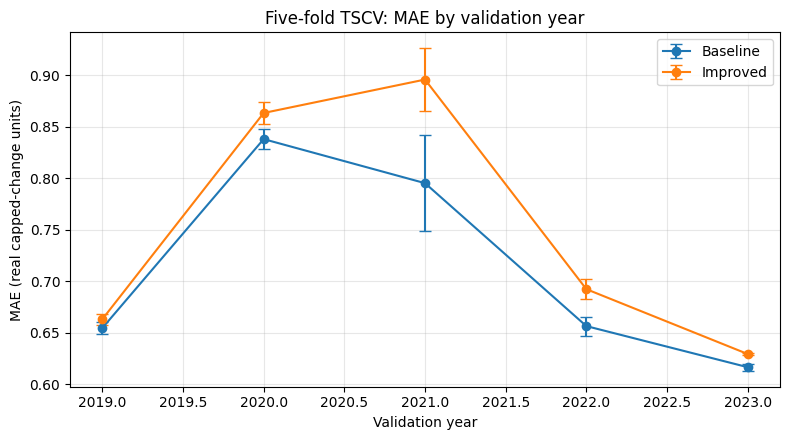

In [12]:
def _load_tscv():
    combined = {}
    for fp in sorted(Path(RESULTS_TSCV_DIR).glob("fold_*.json")):
        with open(fp) as f:
            d = json.load(f)
        combined.setdefault(d["pipeline"], {})[d["fold_year"]] = d["summary"]
    if "Five-fold TSCV" in all_results:
        for pipe, folds in all_results["Five-fold TSCV"].items():
            for vy, summ in folds.items():
                combined.setdefault(pipe, {})[vy] = summ
    return combined


tscv = _load_tscv()
rows = []
for vy in FOLD_YEARS:
    row = {"Validation year": vy}
    for pipeline in ["Baseline", "Improved"]:
        summ = tscv.get(pipeline, {}).get(vy)
        row[f"{pipeline} MAE"] = round(summ["Overall"]["mae"][0], 4) if summ else None
        row[f"{pipeline} nMAE %"] = round(summ["Overall"]["nmae_pct"][0], 1) if summ else None
    rows.append(row)

present = [vy for vy in FOLD_YEARS
           if all(tscv.get(p, {}).get(vy) for p in ["Baseline", "Improved"])]
if present:
    mean_row = {"Validation year": "Mean across folds"}
    for pipeline in ["Baseline", "Improved"]:
        maes = [tscv[pipeline][vy]["Overall"]["mae"][0] for vy in present]
        nmaes = [tscv[pipeline][vy]["Overall"]["nmae_pct"][0] for vy in present]
        mean_row[f"{pipeline} MAE"] = round(float(np.mean(maes)), 4)
        mean_row[f"{pipeline} nMAE %"] = round(float(np.mean(nmaes)), 1)
    rows.append(mean_row)

print("=== Five-fold TSCV: Overall MAE and nMAE per validation year "
      "(real capped-change units, mean +/- std over seeds) ===")
display(pd.DataFrame(rows))

fig, ax = plt.subplots(figsize=(8, 4.5))
for pipeline, color in [("Baseline", "tab:blue"), ("Improved", "tab:orange")]:
    vys = [vy for vy in FOLD_YEARS if tscv.get(pipeline, {}).get(vy)]
    if not vys:
        continue
    maes = [tscv[pipeline][vy]["Overall"]["mae"][0] for vy in vys]
    stds = [tscv[pipeline][vy]["Overall"]["mae"][1] for vy in vys]
    ax.errorbar(vys, maes, yerr=stds, marker="o", capsize=4, label=pipeline, color=color)
ax.set_xlabel("Validation year")
ax.set_ylabel("MAE (real capped-change units)")
ax.set_title("Five-fold TSCV: MAE by validation year")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/tscv_mae_by_year.png", dpi=150)
plt.show()

## Config 1 - Final single split - Baseline

=== Final single split | Baseline (statics: 3) ===
  Split: train <= 2022 (4333), val 2023-2023 (462), test > 2023 (917)
  run 5/20: Overall MAE so far 0.6053
  run 10/20: Overall MAE so far 0.6012
  run 15/20: Overall MAE so far 0.6000
  run 20/20: Overall MAE so far 0.5991

Baseline final test (n=20 runs):
  EBITDA     : 0.4368 +/- 0.0313
  Net_Income : 0.6909 +/- 0.0203
  ROA        : 0.6692 +/- 0.0204
  Overall    : 0.5991 +/- 0.0201
  Scale-free metrics (capped targets):
    EBITDA     : nMAE 103.3% +/- 7.4% | R2 0.061 +/- 0.040
    Net_Income : nMAE 100.3% +/- 3.0% | R2 0.024 +/- 0.025
    ROA        : nMAE 100.6% +/- 3.1% | R2 0.019 +/- 0.030
Time: 9.3 min


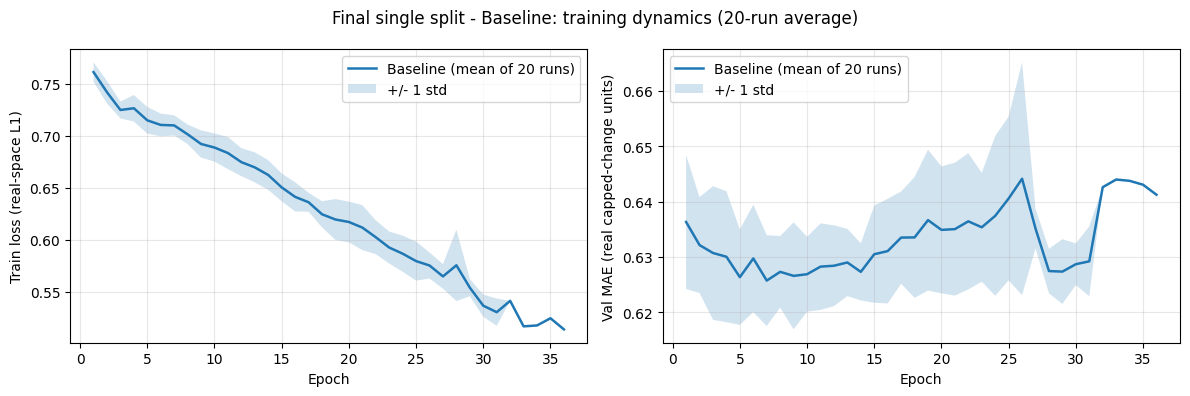

{'EBITDA': {'mae': (0.43681219816207884, 0.03126045678117256),
  'nmae_pct': (103.3120085722903, 7.393521958724872),
  'r2': (0.06130571718697031, 0.040245331643078475)},
 'Net_Income': {'mae': (0.6908502638339996, 0.0203314732582641),
  'nmae_pct': (100.34589658659023, 2.9531434231557565),
  'r2': (0.02398474082093712, 0.02491416283604544)},
 'ROA': {'mae': (0.6692171096801758, 0.020381277394651114),
  'nmae_pct': (100.58388751403815, 3.0633229234615995),
  'r2': (0.0190082528268486, 0.029929316501079467)},
 'Overall': {'mae': (0.5991366897413741, 0.020055880932478932),
  'nmae_pct': (101.41393089097292, 3.751390822047918),
  'r2': (0.03476623694491867, 0.024226347348427785)}}

In [13]:
run_pipeline(CONFIGS[0], "Baseline", is_improved=False, params=PARAMS_BASELINE)

## Config 1 - Final single split - Improved

=== Final single split | Improved (statics: 3) ===
  Split: train <= 2022 (4333), val 2023-2023 (462), test > 2023 (917)
  run 5/20: Overall MAE so far 0.6000
  run 10/20: Overall MAE so far 0.6029
  run 15/20: Overall MAE so far 0.6034
  run 20/20: Overall MAE so far 0.6045

Improved final test (n=20 runs):
  EBITDA     : 0.4389 +/- 0.0129
  Net_Income : 0.7004 +/- 0.0098
  ROA        : 0.6737 +/- 0.0067
  Overall    : 0.6045 +/- 0.0087
  Scale-free metrics (capped targets):
    EBITDA     : nMAE 103.8% +/- 3.1% | R2 -0.004 +/- 0.007
    Net_Income : nMAE 101.7% +/- 1.4% | R2 0.000 +/- 0.004
    ROA        : nMAE 101.3% +/- 1.0% | R2 -0.002 +/- 0.003
Time: 11.7 min


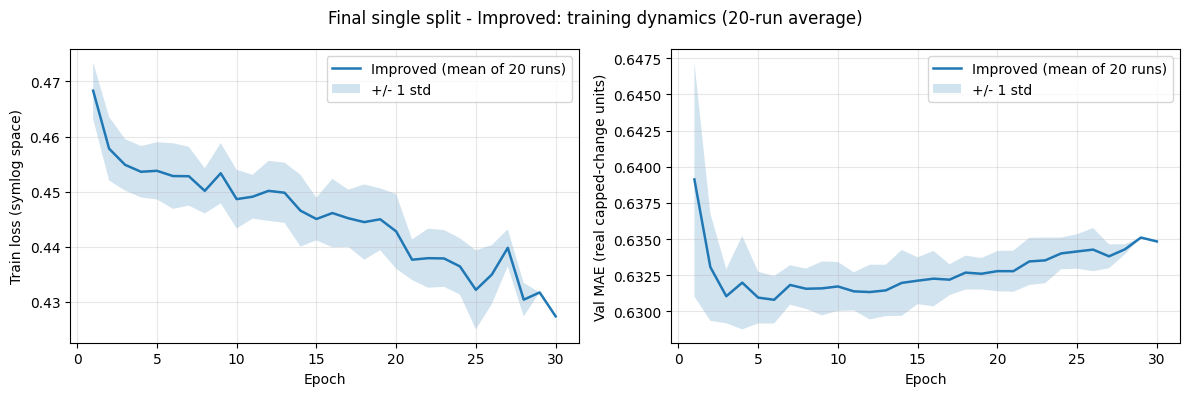

{'EBITDA': {'mae': (0.43892967849969866, 0.012930304014384967),
  'nmae_pct': (103.81280675294734, 3.0581918189957324),
  'r2': (-0.003773326727815313, 0.00662930290799444)},
 'Net_Income': {'mae': (0.7004144787788391, 0.009829435722414018),
  'nmae_pct': (101.73509736428204, 1.427724055618072),
  'r2': (0.00015132624792719152, 0.0041844712896183245)},
 'ROA': {'mae': (0.6736966818571091, 0.006730323133387749),
  'nmae_pct': (101.25718907599087, 1.0115733391789268),
  'r2': (-0.0016262867945326886, 0.0034443153009957655)},
 'Overall': {'mae': (0.6045273381025245, 0.008734681629139278),
  'nmae_pct': (102.26836439774009, 1.6384100546933138),
  'r2': (-0.0017494290914736033, 0.00390963231115183)}}

In [14]:
run_pipeline(CONFIGS[0], "Improved", is_improved=True, params=PARAMS_IMPROVED)

## Config 2 - With balance-sheet statics - Baseline

=== With balance-sheet statics | Baseline (statics: 6) ===
  Split: train <= 2022 (4333), val 2023-2023 (462), test > 2023 (917)
  run 5/20: Overall MAE so far 0.6116
  run 10/20: Overall MAE so far 0.6045
  run 15/20: Overall MAE so far 0.6048
  run 20/20: Overall MAE so far 0.6052

Baseline final test (n=20 runs):
  EBITDA     : 0.4467 +/- 0.0254
  Net_Income : 0.6963 +/- 0.0220
  ROA        : 0.6719 +/- 0.0167
  Overall    : 0.6052 +/- 0.0165
  Scale-free metrics (capped targets):
    EBITDA     : nMAE 105.7% +/- 6.0% | R2 0.035 +/- 0.038
    Net_Income : nMAE 101.1% +/- 3.2% | R2 0.023 +/- 0.023
    ROA        : nMAE 101.0% +/- 2.5% | R2 0.017 +/- 0.022
Time: 11.6 min


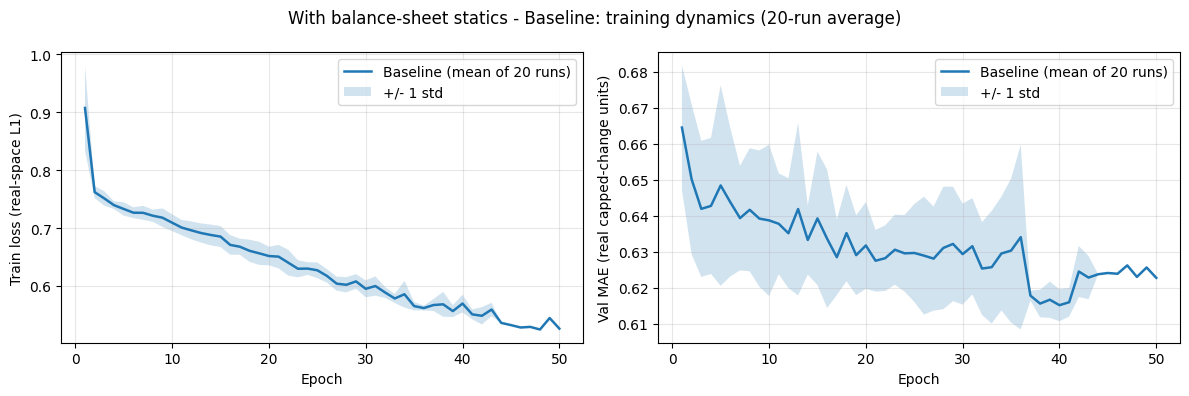

{'EBITDA': {'mae': (0.4467309057712555, 0.025421531510668463),
  'nmae_pct': (105.65791743165116, 6.012536949291934),
  'r2': (0.034504927541754896, 0.03828188113807578)},
 'Net_Income': {'mae': (0.696327668428421, 0.022023368168696544),
  'nmae_pct': (101.14148877750065, 3.1988909036234268),
  'r2': (0.022554902100066054, 0.02309047411043169)},
 'ROA': {'mae': (0.6719014763832092, 0.016667657695288503),
  'nmae_pct': (100.98735005944945, 2.505162797685496),
  'r2': (0.017218334616801133, 0.02170666390258449)},
 'Overall': {'mae': (0.6051592648722329, 0.016474395268053648),
  'nmae_pct': (102.59558542286709, 3.0049941878207536),
  'r2': (0.024759388086207357, 0.023406019334804573)}}

In [15]:
run_pipeline(CONFIGS[1], "Baseline", is_improved=False, params=PARAMS_BASELINE)

## Config 2 - With balance-sheet statics - Improved

=== With balance-sheet statics | Improved (statics: 6) ===
  Split: train <= 2022 (4333), val 2023-2023 (462), test > 2023 (917)
  run 5/20: Overall MAE so far 0.6141
  run 10/20: Overall MAE so far 0.6083
  run 15/20: Overall MAE so far 0.6063
  run 20/20: Overall MAE so far 0.6056

Improved final test (n=20 runs):
  EBITDA     : 0.4380 +/- 0.0206
  Net_Income : 0.7016 +/- 0.0094
  ROA        : 0.6767 +/- 0.0129
  Overall    : 0.6056 +/- 0.0121
  Scale-free metrics (capped targets):
    EBITDA     : nMAE 103.6% +/- 4.9% | R2 -0.008 +/- 0.015
    Net_Income : nMAE 101.9% +/- 1.4% | R2 -0.002 +/- 0.005
    ROA        : nMAE 101.7% +/- 1.9% | R2 -0.005 +/- 0.010
Time: 14.0 min


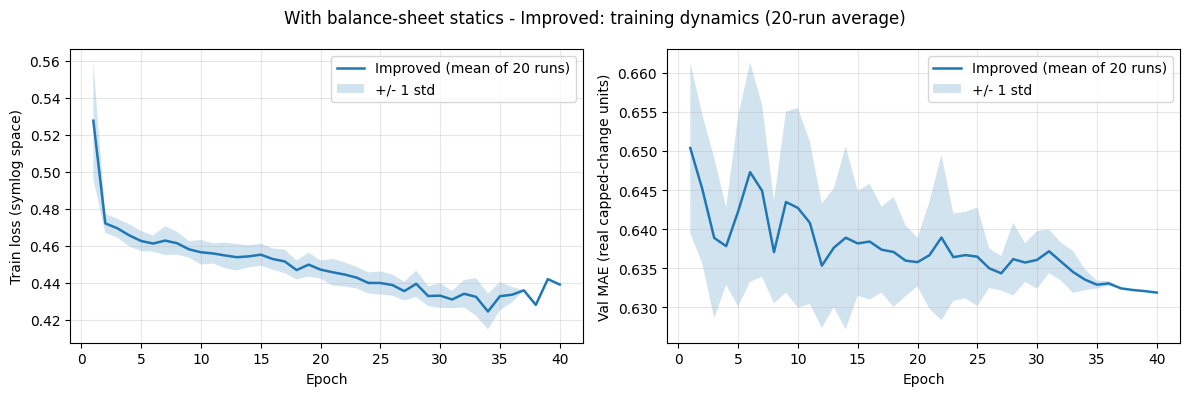

{'EBITDA': {'mae': (0.4379649683833122, 0.020556483961147946),
  'nmae_pct': (103.58463975993982, 4.861886542448002),
  'r2': (-0.007847311705025523, 0.014731799771969189)},
 'Net_Income': {'mae': (0.7016451954841614, 0.009424041186897415),
  'nmae_pct': (101.91385878003992, 1.3688405605001015),
  'r2': (-0.0024053149527544283, 0.005394765395131548)},
 'ROA': {'mae': (0.6766939491033555, 0.012926142764769662),
  'nmae_pct': (101.70768091369419, 1.9428103435919017),
  'r2': (-0.005004631644736096, 0.010468569698679833)},
 'Overall': {'mae': (0.6056173325062301, 0.012116041120508453),
  'nmae_pct': (102.40205981789128, 2.3506383121177645),
  'r2': (-0.005085752767505349, 0.008102374370724624)}}

In [16]:
run_pipeline(CONFIGS[1], "Improved", is_improved=True, params=PARAMS_IMPROVED)

## Summary

In [17]:
# Summary over the configurations completed so far. Falls back to the JSON
# files in results_winsorized_splits/ if the kernel was restarted, so this cell
# works even after a Colab disconnect.

def _load_payload(name, pipeline):
    if name in all_results and pipeline in all_results[name]:
        return all_results[name][pipeline]
    slug = f"{name.lower().replace(' ', '_')}_{pipeline.lower()}"
    fpath = Path(RESULTS_DIR) / f"{slug}.json"
    if fpath.exists():
        with open(fpath) as f:
            return json.load(f)["summary"]
    return None


rows, detail_rows = [], []
for cfg in CONFIGS:
    name = cfg["name"]
    row = {"Split configuration": name}
    for pipeline in ["Baseline", "Improved"]:
        payload = _load_payload(name, pipeline)
        m_key = f"{pipeline} MAE"
        n_key = f"{pipeline} nMAE %"
        row[m_key] = round(payload["Overall"]["mae"][0], 4) if payload else None
        row[n_key] = round(payload["Overall"]["nmae_pct"][0], 1) if payload else None
        if payload is not None:
            for t in PREDICTION_TARGETS:
                detail_rows.append({
                    "Split configuration": name, "Pipeline": pipeline, "Target": t,
                    "MAE": round(payload[t]["mae"][0], 4), "MAE +/-": round(payload[t]["mae"][1], 4),
                    "nMAE %": round(payload[t]["nmae_pct"][0], 1), "nMAE +/-": round(payload[t]["nmae_pct"][1], 1),
                    "R2": round(payload[t]["r2"][0], 3), "R2 +/-": round(payload[t]["r2"][1], 3),
                })
    rows.append(row)

print("=== Overall test MAE and nMAE (real capped-change units), mean over {} runs ===".format(N_RUNS))
display(pd.DataFrame(rows))

detail = pd.DataFrame(detail_rows)
if not detail.empty:
    print("\n=== Per-target detail ===")
    display(detail)
else:
    print("No results yet - run the configuration cells above.")

=== Overall test MAE and nMAE (real capped-change units), mean over 20 runs ===


,Split configuration,Baseline MAE,Baseline nMAE %,Improved MAE,Improved nMAE %
0,Final single split,0.5991,101.4,0.6045,102.3
1,With balance-sheet statics,0.6052,102.6,0.6056,102.4



=== Per-target detail ===


,Split configuration,Pipeline,Target,MAE,MAE +/-,nMAE %,nMAE +/-,R2,R2 +/-
0,Final single split,Baseline,EBITDA,0.4368,0.0313,103.3,7.4,0.061,0.040
1,Final single split,Baseline,Net_Income,0.6909,0.0203,100.3,3.0,0.024,0.025
2,Final single split,Baseline,ROA,0.6692,0.0204,100.6,3.1,0.019,0.030
3,Final single split,Improved,EBITDA,0.4389,0.0129,103.8,3.1,-0.004,0.007
4,Final single split,Improved,Net_Income,0.7004,0.0098,101.7,1.4,0.000,0.004
5,Final single split,Improved,ROA,0.6737,0.0067,101.3,1.0,-0.002,0.003
6,With balance-sheet statics,Baseline,EBITDA,0.4467,0.0254,105.7,6.0,0.035,0.038
7,With balance-sheet statics,Baseline,Net_Income,0.6963,0.0220,101.1,3.2,0.023,0.023
8,With balance-sheet statics,Baseline,ROA,0.6719,0.0167,101.0,2.5,0.017,0.022
9,With balance-sheet statics,Improved,EBITDA,0.4380,0.0206,103.6,4.9,-0.008,0.015
